# 1) HT and Comp. Avg Plot

Loading data using evalviz (same as comp_benchmarks_tables.ipynb)...
Available run labels: ['CE CLIP', 'CLIC CogVLM (LAION)', 'CLIC CogVLM (PixPR RedCaps)', 'CLIP', 'CLoVe', 'CON CLIP', 'CS-CLIP', 'DAC (LLM)', 'DAC (SAM)', 'DeGLA', 'FSC CLIP (CC3M)', 'FSC CLIP (COCO)', 'FSC CLIP (LAION+COCO)', 'LaCLIP (CC12M)', 'LabCLIP', 'NegCLIP (COCO)', 'READCLIP', 'TSVLC', 'TripletCLIP (CC12M)']
  ✓ CLIP: Comp=52.08, HT=40.57
  ✓ NegCLIP: Comp=55.34, HT=56.50
  ✗ CyCLIP: Missing data (run_label='CyCLIP', comp=None, ht=None)
  ✗ SigLIP: Missing data (run_label='SigLIP', comp=None, ht=45.68997286341251)
  ✓ NegCLIP: Comp=55.34, HT=56.50
  ✗ CyCLIP: Missing data (run_label='CyCLIP', comp=None, ht=None)
  ✗ SigLIP: Missing data (run_label='SigLIP', comp=None, ht=45.68997286341251)
  ✗ SigLIP2: Missing data (run_label='SigLIP2', comp=None, ht=54.62494555931522)
  ✓ CE-CLIP: Comp=54.38, HT=49.12
  ✗ SigLIP2: Missing data (run_label='SigLIP2', comp=None, ht=54.62494555931522)
  ✓ CE-CLIP: Comp=54.38, HT=4

/tmp/ipykernel_1575345/3319840910.py:343: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=0.3)


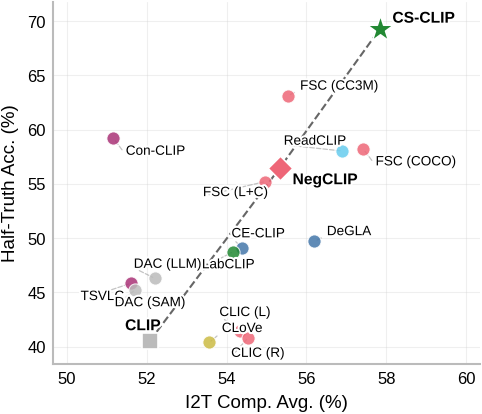


Figure saved as ht_vs_comp_scatter.pdf and ht_vs_comp_scatter.png


In [1]:
# --- Modern scatter plot: I2T Compositional Avg vs Half-Truth Accuracy ---
# Load data using evalviz (same as comp_benchmarks_tables.ipynb)

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from pathlib import Path

import tueplots
from tueplots import figsizes, fontsizes
from tueplots.constants.color import palettes

# Import evalviz - same approach as comp_benchmarks_tables.ipynb
import sys
sys.path.insert(0, str(Path("..").resolve()))
from evalviz.config import load_runs_from_files, load_methods, load_benchmarks
from evalviz.io import load_results_from_runs
from evalviz.preprocess import apply_mappings, add_dataset_type_columns, apply_dataset_merge_rules
from evalviz.enrich import attach_method_metadata, attach_benchmark_metadata

# ICML 2024 configuration
icml_size = figsizes.icml2024_full()
plt.rcParams.update(figsizes.icml2024_full())
plt.rcParams.update(fontsizes.icml2024())

# Use a clean style with black text
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['text.color'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'

# Use tueplots built-in colorblind-friendly palette (Paul Tol's bright)
COLORBLIND_PALETTE = [f"#{c}" if not c.startswith("#") else c for c in palettes.paultol_bright]

# Key model colors from the palette
KEY_COLORS = {
    "CLIP": COLORBLIND_PALETTE[-1],     # grey - baseline
    "NegCLIP": COLORBLIND_PALETTE[1],   # red - intermediate  
    "CS-CLIP": COLORBLIND_PALETTE[2],   # green - best (ours)
}

# =============================================================================
# PATHS AND CONFIG
# =============================================================================
BASE_DIR = Path("..").resolve()
HALFTRUTH_DIR = BASE_DIR.parent / "results_new"

# =============================================================================
# LOAD COMPOSITIONAL DATA USING EVALVIZ (same as comp_benchmarks_tables.ipynb)
# =============================================================================
runs = load_runs_from_files(
    "../configs/runs_baselines.json",
    "../configs/runs_external.json",
    "../configs/runs_ours_final.json"
)
methods = load_methods("../configs/methods.json")
bench_cfg = load_benchmarks("../configs/benchmarks.json")

df = load_results_from_runs(runs)
df = apply_dataset_merge_rules(df, bench_cfg)
df = apply_mappings(df, bench_cfg)
df = add_dataset_type_columns(df)
df = attach_method_metadata(df, methods)
df = attach_benchmark_metadata(df, bench_cfg)

# =============================================================================
# COMPUTE COMPOSITIONAL AVERAGES (correct hierarchical averaging)
# =============================================================================
def compute_compositional_avg(df, run_label, metric="text_contrastive_accuracy"):
    """Compute compositional average with correct hierarchical averaging:
    1. Average within each (dataset, subset) - handles duplicates
    2. Average across subsets within each dataset - equal weight per subset  
    3. Average across datasets
    """
    d = df[(df["run_label"] == run_label) & 
           (df["benchmark_type"] == "compositional") & 
           (df["metric"] == metric)].copy()
    
    if d.empty:
        return None
    
    d["value"] = pd.to_numeric(d["value"], errors="coerce")
    
    # Hierarchical averaging: subset -> dataset -> overall
    subset_avg = d.groupby(["dataset", "subset"], as_index=False)["value"].mean()
    dataset_avg = subset_avg.groupby("dataset")["value"].mean()
    overall_avg = dataset_avg.mean() * 100
    
    return overall_avg

# =============================================================================
# MODEL CONFIGS: display_name -> (run_label in evalviz, ht_folder)
# run_label must match the "label" field in runs_*.json configs
# =============================================================================
MODEL_CONFIGS = {
    # Baselines
    "CLIP": ("CLIP", "half_truth_coco_00_baseline_openai_vitb32"),
    "NegCLIP": ("NegCLIP (COCO)", "half_truth_coco_negclip_coco_vitb32"),
    "CyCLIP": ("CyCLIP", "half_truth_coco_cyclip_vitb32"),
    "SigLIP": ("SigLIP", "half_truth_coco_siglip_vitb16"),
    "SigLIP2": ("SigLIP2", "half_truth_coco_siglip2_vitb16"),
    # External methods
    "CE-CLIP": ("CE CLIP", "half_truth_coco_ce_clip_vitb32"),
    "Con-CLIP": ("CON CLIP", "half_truth_coco_con_clip_vitb32"),
    "FSC-CLIP (CC3M)": ("FSC CLIP (CC3M)", "half_truth_coco_fsc_clip_cc3m_vitb32"),
    "FSC-CLIP (COCO)": ("FSC CLIP (COCO)", "half_truth_coco_fsc_clip_coco_vitb32"),
    "FSC-CLIP (LAION+COCO)": ("FSC CLIP (LAION+COCO)", "half_truth_coco_fsc_clip_laioncoco_vitb32"),
    "CLIC (CogVLM LAION)": ("CLIC CogVLM (LAION)", "half_truth_coco_clic_cogvlm_vitb32_laion"),
    "CLIC (CogVLM RedCaps)": ("CLIC CogVLM (PixPR RedCaps)", "half_truth_coco_clic_cogvlm_vitb32_pixpr_redcaps"),
    "ReadCLIP": ("READCLIP", "half_truth_coco_readclip_vitb32"),
    "TSVLC": ("TSVLC", "half_truth_coco_tsvlc_vitb32"),
    "DAC (LLM)": ("DAC (LLM)", "half_truth_coco_dac_vitb32_llm"),
    "DAC (SAM)": ("DAC (SAM)", "half_truth_coco_dac_vitb32_sam"),
    "DeGLA": ("DeGLA", "half_truth_coco_degla_vitb32"),
    "CLoVe": ("CLoVe", "half_truth_coco_clove_vitb32_laioncoco"),
    "LabCLIP": ("LabCLIP", "half_truth_coco_labclip_vitb32"),
    # Ours
    "CS-CLIP": ("CS-CLIP", "half_truth_coco_cs_clip_negclip_vitb32"),
}

def load_halftruth_metrics(folder_name, base_dir=HALFTRUTH_DIR):
    """Load Half-Truth metrics from results.json."""
    full_path = base_dir / folder_name
    results_file = full_path / 'results.json'
    
    if not results_file.exists():
        return None
    
    with open(results_file, 'r') as f:
        data = json.load(f)
    
    if 'results' in data:
        ht_df = pd.DataFrame(data['results'])
    else:
        ht_df = pd.DataFrame(data)
    
    ht_df = ht_df[ht_df['condition'] != 'relation_negation']
    
    # Re-compute from raw scores: ST wins only if strictly greater (ties go to HT)
    st_wins = (ht_df['score_short_correct'] > ht_df['score_long_incorrect']).astype(float)
    overall_ht_acc = st_wins.mean() * 100
    
    return overall_ht_acc

# =============================================================================
# LOAD DATA FOR ALL MODELS
# =============================================================================
print("Loading data using evalviz (same as comp_benchmarks_tables.ipynb)...")

# Debug: show available run labels
available_runs = sorted(df["run_label"].unique())
print(f"Available run labels: {available_runs}")

records = []
for display_name, (run_label, ht_folder) in MODEL_CONFIGS.items():
    comp_avg = compute_compositional_avg(df, run_label)
    ht_acc = load_halftruth_metrics(ht_folder)
    
    if comp_avg is not None and ht_acc is not None:
        records.append({
            "name": display_name,
            "x": comp_avg,
            "y": ht_acc,
        })
        print(f"  ✓ {display_name}: Comp={comp_avg:.2f}, HT={ht_acc:.2f}")
    else:
        print(f"  ✗ {display_name}: Missing data (run_label='{run_label}', comp={comp_avg}, ht={ht_acc})")

print(f"\nLoaded {len(records)} models successfully.")

if not records:
    raise ValueError("No plottable records found.")

# =============================================================================
# HELPERS (from original plot)
# =============================================================================
def family_and_variant(name: str):
    n = name.strip()
    if "(" in n and n.endswith(")"):
        fam = n.split("(")[0].strip()
        var = n[n.find("(")+1:-1].strip()
        return fam, var
    if n.startswith("DAC"):
        return "DAC", n.replace("DAC", "").strip() or "base"
    if n.startswith("CLIC"):
        return "CLIC", n.replace("CLIC", "").strip() or "base"
    if n.startswith("FSC-CLIP"):
        return "FSC-CLIP", n.replace("FSC-CLIP", "").strip() or "base"
    if n in {"CLIP", "NegCLIP", "CS-CLIP"}:
        return n, "base"
    return n, "base"

# Add family info to records
for r in records:
    fam, var = family_and_variant(r["name"])
    r["family"] = fam
    r["variant"] = var

# Color palette - colorblind-friendly
families = sorted({r["family"] for r in records})
family_to_color = {fam: COLORBLIND_PALETTE[i % len(COLORBLIND_PALETTE)] for i, fam in enumerate(families)}

# Key models for progression line
KEY_MODELS = ["CLIP", "NegCLIP", "CS-CLIP"]
key_coords = {r["name"]: (r["x"], r["y"]) for r in records if r["name"] in KEY_MODELS}

# =============================================================================
# PLOT - COMPACT WITH LARGER LABELS AND TIGHTER LAYOUT
# =============================================================================
# Calculate data bounds to set tight axis limits
x_vals = [r["x"] for r in records]
y_vals = [r["y"] for r in records]
x_range = max(x_vals) - min(x_vals)
y_range = max(y_vals) - min(y_vals)

# Tight figure - slightly taller aspect ratio to reduce empty space
fig, ax = plt.subplots(figsize=(3.25, 2.8), dpi=150)

# Set tight axis limits FIRST (with small padding)
ax.set_xlim(min(x_vals) - 1.5, max(x_vals) + 2.5)
ax.set_ylim(min(y_vals) - 2, max(y_vals) + 2.5)

# Draw simple dashed line connecting CLIP -> NegCLIP -> CS-CLIP
line_x = [key_coords[m][0] for m in KEY_MODELS if m in key_coords]
line_y = [key_coords[m][1] for m in KEY_MODELS if m in key_coords]
ax.plot(line_x, line_y, linestyle="--", color="#666666", lw=1.0, zorder=1)

# Draw all points - LARGER markers
for r in records:
    color = family_to_color[r["family"]]
    is_key = r["name"] in KEY_MODELS
    
    if r["name"] == "CS-CLIP":
        size, edge, lw, marker, c = 180, "white", 0.8, "*", KEY_COLORS["CS-CLIP"]
    elif r["name"] == "NegCLIP":
        size, edge, lw, marker, c = 70, "white", 0.8, "D", KEY_COLORS["NegCLIP"]
    elif r["name"] == "CLIP":
        size, edge, lw, marker, c = 60, "white", 0.8, "s", KEY_COLORS["CLIP"]
    else:
        size, edge, lw, marker, c = 40, "white", 0.5, "o", color
    
    alpha = 1.0 if is_key else 0.85
    zorder = 10 if is_key else 3

    ax.scatter(
        r["x"], r["y"],
        s=size, c=c,
        marker=marker,
        edgecolor=edge,
        linewidth=lw,
        alpha=alpha, zorder=zorder
    )

# Label positioning - tuned for tight layout with LARGER fonts
label_offsets = {
    "CS-CLIP": (6, 3),
    "NegCLIP": (6, -8),
    "CLIP": (-12, 5),
    "FSC-CLIP (CC3M)": (6, 3),
    "FSC-CLIP (COCO)": (6, -8),
    "FSC-CLIP (LAION+COCO)": (-30, -7),   # Reduced left margin
    "ReadCLIP": (-28, 3),                 # Closer (reduced left margin)
    "Con-CLIP": (6, -8),
    "DeGLA": (6, 3),
    "CE-CLIP": (-5, 5),                  # A bit more left
    "DAC (LLM)": (-10, 5),                # A bit more left
    "DAC (SAM)": (-10, -8),               # Moved to the left
    "CLIC (CogVLM LAION)": (-10, 7),    # More left and down
    "CLIC (CogVLM RedCaps)": (-8, -9),
    "TSVLC": (-24, -8),
    "CLoVe": (6, 5),
    "LabCLIP": (-15, -8),                 # A bit more left
    "CyCLIP": (6, 3),
    "SigLIP": (6, -8),
    "SigLIP2": (6, 3),
}

# Display labels - shorter names for variants
label_display = {
    "FSC-CLIP (LAION+COCO)": "FSC (L+C)",
    "FSC-CLIP (CC3M)": "FSC (CC3M)",
    "FSC-CLIP (COCO)": "FSC (COCO)",
    "CLIC (CogVLM LAION)": "CLIC (L)",
    "CLIC (CogVLM RedCaps)": "CLIC (R)",
}

for r in records:
    label = label_display.get(r["name"], r["name"])
    is_key = r["name"] in KEY_MODELS
    offset = label_offsets.get(r["name"], (6, 3))
    
    # LARGER fonts: 7.5 for key models, 6.5 for others
    fontsize = 7.5 if is_key else 6.5
    weight = "bold" if is_key else "normal"
    
    # Add leader line for non-key models (subtle dashed line from point to label)
    if not is_key:
        ax.annotate(
            "",
            xy=(r["x"], r["y"]),
            xytext=offset,
            textcoords="offset points",
            arrowprops=dict(
                arrowstyle="-",
                linestyle="--",
                color="#888888",
                alpha=0.5,
                linewidth=0.6,
                shrinkA=3,  # Shrink from point
                shrinkB=1,  # Shrink from text
            ),
            zorder=2
        )
    
    ax.annotate(
        label,
        (r["x"], r["y"]),
        textcoords="offset points",
        xytext=offset,
        fontsize=fontsize,
        fontweight=weight,
        color="black",
        zorder=100,
        path_effects=[pe.withStroke(linewidth=2.0, foreground="white")]
    )

# Axes labels - larger
ax.set_xlabel("I2T Comp. Avg. (%)", fontsize=9)
ax.set_ylabel("Half-Truth Acc. (%)", fontsize=9)

# Style
ax.set_facecolor("white")
ax.grid(True, alpha=0.3, linestyle="-", linewidth=0.5, color="#cccccc")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#bbbbbb")
ax.spines["bottom"].set_color("#bbbbbb")
ax.tick_params(colors="black", labelsize=8)

plt.tight_layout(pad=0.3)
plt.savefig("ht_vs_comp_scatter.pdf", bbox_inches="tight", dpi=150)
plt.savefig("ht_vs_comp_scatter.png", bbox_inches="tight", dpi=150)
plt.show()

print("\nFigure saved as ht_vs_comp_scatter.pdf and ht_vs_comp_scatter.png")

In [2]:
# =============================================================================
# SPEARMAN CORRELATION: I2T Compositional Avg vs Half-Truth Accuracy
# =============================================================================
from scipy.stats import spearmanr, pearsonr

# Extract x and y values from records
x_vals = [r["x"] for r in records]
y_vals = [r["y"] for r in records]

# Calculate Spearman correlation
spearman_corr, spearman_pval = spearmanr(x_vals, y_vals)

# Also calculate Pearson for comparison
pearson_corr, pearson_pval = pearsonr(x_vals, y_vals)

print("=" * 50)
print("CORRELATION ANALYSIS")
print("=" * 50)
print(f"Number of models: {len(records)}")
print()
print(f"Spearman correlation: ρ = {spearman_corr:.3f}")
print(f"Spearman p-value:     p = {spearman_pval:.2e}")
print()
print(f"Pearson correlation:  r = {pearson_corr:.3f}")
print(f"Pearson p-value:      p = {pearson_pval:.2e}")
print("=" * 50)

# Interpretation
if spearman_pval < 0.001:
    sig = "highly significant (p < 0.001)"
elif spearman_pval < 0.01:
    sig = "very significant (p < 0.01)"
elif spearman_pval < 0.05:
    sig = "significant (p < 0.05)"
else:
    sig = "not significant (p >= 0.05)"

print(f"\nInterpretation: The correlation is {sig}.")
if abs(spearman_corr) > 0.7:
    strength = "strong"
elif abs(spearman_corr) > 0.4:
    strength = "moderate"
else:
    strength = "weak"
direction = "positive" if spearman_corr > 0 else "negative"
print(f"There is a {strength} {direction} monotonic relationship between")
print(f"I2T Compositional Avg and Half-Truth Accuracy.")

CORRELATION ANALYSIS
Number of models: 17

Spearman correlation: ρ = 0.574
Spearman p-value:     p = 1.61e-02

Pearson correlation:  r = 0.579
Pearson p-value:      p = 1.48e-02

Interpretation: The correlation is significant (p < 0.05).
There is a moderate positive monotonic relationship between
I2T Compositional Avg and Half-Truth Accuracy.
